In [25]:
import matplotlib.pyplot as plt
import io
import base64
from IPython.display import display, HTML

# Добавляем CSS для глобального применения прокрутки к графикам
display(HTML("""
    <style>
        .scrollable-output {
            max-height: 300px;
            overflow-y: auto;
            border: 1px solid #ddd;
            padding: 5px;
        }
    </style>
"""))

def scrollable_plot(fig, height=400):
    """Выводит matplotlib figure в прокручиваемом контейнере"""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches='tight')
    buf.seek(0)
    img_base64 = base64.b64encode(buf.getvalue()).decode()
    
    html = f"""
    <div class="scrollable-output" style="max-height: {height}px;">
        <img src="data:image/png;base64,{img_base64}">
    </div>
    """
    plt.close(fig)  # Закрываем фигуру, чтобы избежать двойного вывода
    display(HTML(html))

# Пример использования
# fig, ax = plt.subplots(figsize=(10, 5))
# ax.plot(range(10), range(10))
# scrollable_plot(fig)


In [33]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import os
import cv2
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
%matplotlib inline
plt.rcParams["image.cmap"] = 'magma'
import seaborn as sns
from tqdm.notebook import tqdm
from tabulate import tabulate

from sklearn.metrics.pairwise import cosine_similarity

from damo.config.base import parse_config
from tools.demo import Infer

from my_help_functions.hooks import register_conv_bn_hooks
from my_help_functions.cosine_matrix import get_positions_of_classes_on_flattened_image, get_positions_of_classes_on_flattened_image_for_collage

from my_help_functions.hooks import register_hooks_batch_forward
from damo.config.base import parse_config
from damo.detectors.detector import build_local_model

In [ ]:
# config = parse_config('./configs/damoyolo_tinynasL20_T.py')

# infer_engine = Infer(config, device='cuda',
#     ckpt='./weights/damoyolo_tiny.pth')

# model = infer_engine.model.eval()

Inference with torch engine!


In [28]:
# savefig = False

# idx = 5
# path = f'./collage/gray_collage_background_centroid_{idx}.jpg'

In [2]:
# for name, layer in list(model.named_modules())[:1]:
#     print(name, layer)

In [30]:
def load_images_from_folder(folder):
    img_list = []
    names = []
    for filename in sorted(os.listdir(folder)):
        if filename.lower().endswith(".jpg"):
            path = os.path.join(folder, filename)
            img = cv2.imread(path)
            if img is not None:
                img_list.append(img)
                names.append(filename)
    return img_list, names

def load_images_from_folder_coco(folder):
    img_list = []
    names = []
    i = 0
    for filename in sorted(os.listdir(folder)):
        if filename.lower().endswith(".jpg"):
            path = os.path.join(folder, filename)
            img = cv2.imread(path)
            if img is not None:
                img_list.append(img)
                names.append(filename.split('.')[0])
        i += 1
        if i == 64: break
    return img_list, names

In [31]:
from damo.dataset.transforms import transforms as T
from damo.structures.image_list import to_image_list

def transform_img_(origin_img, size_divisibility=0, image_max_range=(640, 640), flip_prob=0.0,
                  image_mean=[0.0, 0.0, 0.0], image_std=[1.0, 1.0, 1.0], keep_ratio=False, infer_size=[640,640]):
    transform = [
        T.Resize(image_max_range, target_size=infer_size, keep_ratio=keep_ratio),
        T.RandomHorizontalFlip(flip_prob),
        T.ToTensor(),
        T.Normalize(mean=image_mean, std=image_std),
    ]
    transform = T.Compose(transform)

    img, _ = transform(origin_img)
    img = to_image_list(img, size_divisibility)
    return img

In [32]:
def run_batch_inference(config_path, ckpt_path, img_folder, model_desired_layers, device='cuda'):
    config = parse_config(config_path)
    model = build_local_model(config, device)
    model.to(device)

    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt['model'], strict=True)
    layer_outputs_fwd = register_hooks_batch_forward(model, model_desired_layers)

    model.eval()

    global coco_
    imgs, names = load_images_from_folder_coco(img_folder) if coco_ else load_images_from_folder(img_folder)

    # Трансформация + сохранение размеров
    transformed = []
    shapes = []  # (h0, w0, h1, w1)
    for img in imgs:
        h0, w0 = img.shape[:2]
        img_t = transform_img_(img)
        h1, w1 = img_t.tensors.shape[-2:]
        transformed.append(img_t)
        shapes.append((h0, w0, h1, w1))

    image_list = torch.cat([img.tensors for img in transformed], dim=0).to(device)

    with torch.no_grad():
        outputs = model(image_list)

    bboxes = []
    scores = []
    cls_inds = []

    for i in range(len(outputs)):
        boxes = outputs[i].bbox.clone().cpu()

        # рескейлим обратно
        h0, w0, h1, w1 = shapes[i]
        scale_x = w0 / w1
        scale_y = h0 / h1

        boxes[:, 0] *= scale_x
        boxes[:, 2] *= scale_x
        boxes[:, 1] *= scale_y
        boxes[:, 3] *= scale_y

        bboxes.append(boxes)
        scores.append(outputs[i].get_field('scores').cpu())
        cls_inds.append(outputs[i].get_field('labels').cpu())

    return bboxes, scores, cls_inds, names, layer_outputs_fwd, model


In [33]:
coco_ = True

In [34]:
config_path = './configs/damoyolo_tinynasL20_T.py'
ckpt_path = './weights/damoyolo_tiny.pth'
img_folder = './datasets/coco/val2017' if coco_ else './downloaded_images'

layers_to_add = ['backbone.block_list.3.block_list.0.conv1.conv1',
                 'backbone.block_list.3.block_list.0.conv1.bn1'  
                ]

layers_to_add += ['backbone.block_list.3.block_list.0.conv2.rbr_dense.conv',
                 'backbone.block_list.3.block_list.0.conv2.rbr_dense.bn'  
                ]

bboxes, scores, cls_inds, names, fms, model = run_batch_inference(config_path, ckpt_path, img_folder, layers_to_add)

forward hook used
forward hook used
forward hook used
forward hook used


In [35]:
kernel_size_is_1_ = True

In [36]:
conv = {}

if kernel_size_is_1_:
    convolution = model.backbone.block_list[3].block_list[0].conv1.conv1
    bn = model.backbone.block_list[3].block_list[0].conv1.bn1

    conv['before conv'] = list(fms.values())[0][0]
    conv['after conv']  = list(fms.values())[0][1]
    signal_after_bn_true_ = list(fms.values())[1][1]
else:
    convolution = model.backbone.block_list[3].block_list[0].conv2.rbr_dense.conv
    bn = model.backbone.block_list[3].block_list[0].conv2.rbr_dense.bn

    conv['before conv'] = list(fms.values())[2][0]
    conv['after conv']  = list(fms.values())[2][1]
    signal_after_bn_true_ = list(fms.values())[3][1]

center = bn.running_mean

In [37]:
signal = conv['before conv']
signal_after_conv_true = convolution(signal)
signal_after_bn_true = bn(signal_after_conv_true)

forward hook used
forward hook used


In [38]:
W = convolution.weight.data
W_flat = W.view(W.size()[0], -1)  # shape: [out_ch, in_ch * k_size * k_size]

center = bn.running_mean
U, S, Vh = torch.svd(W_flat)


In [39]:
out_ch, in_ch, kH, kW = W.shape
center = bn.running_mean
W_eff = W.view(W.size()[0], W.size()[1], -1).sum(dim=2)  # shape: [out_ch, in_ch]
W_pinv = torch.pinverse(W_eff)        # [rc, out_ch]
center_before = W_pinv @ center

In [ ]:
keep_ratio = 0.95

rank = max(1, int(len(S) * keep_ratio))

U_r = U[:, :rank]
S_r = S[:rank]
Vh_r = Vh[:, :rank]
# U_r = U
# S_r = S
# Vh_r = Vh

dotp = torch.abs(U_r.T @ center_before)
correlated   = torch.nonzero(dotp >= S_r[-1], as_tuple=True)[0]
uncorrelated = torch.nonzero(dotp <  S_r[-1], as_tuple=True)[0]

In [53]:
kr = 0.95
n = torch.norm(S)
remain = n * kr
# cs = torch.cumsum(S, 0)
cs = torch.sqrt(torch.cumsum(S ** 2, 0))
m = cs <= remain
len(m[m == True]), len(S) - len(m[m == True])
res = S[m]
print(torch.norm(res), torch.norm(S))
res, S, len(res)
# len(S) - len(m[m == True])


tensor(1.9328, device='cuda:0') tensor(2.0351, device='cuda:0')


(tensor([0.4920, 0.4229, 0.4084, 0.4065, 0.3826, 0.3673, 0.3628, 0.3569, 0.3542,
         0.3454, 0.3421, 0.3399, 0.3252, 0.3245, 0.3186, 0.3139, 0.3099, 0.3005,
         0.2965, 0.2919, 0.2882, 0.2786, 0.2778, 0.2653, 0.2607, 0.2586, 0.2488,
         0.2452, 0.2384, 0.2341, 0.2299, 0.2240, 0.2167, 0.2113, 0.2081, 0.2049,
         0.1999, 0.1953, 0.1887, 0.1860, 0.1768, 0.1718, 0.1699],
        device='cuda:0'),
 tensor([0.4920, 0.4229, 0.4084, 0.4065, 0.3826, 0.3673, 0.3628, 0.3569, 0.3542,
         0.3454, 0.3421, 0.3399, 0.3252, 0.3245, 0.3186, 0.3139, 0.3099, 0.3005,
         0.2965, 0.2919, 0.2882, 0.2786, 0.2778, 0.2653, 0.2607, 0.2586, 0.2488,
         0.2452, 0.2384, 0.2341, 0.2299, 0.2240, 0.2167, 0.2113, 0.2081, 0.2049,
         0.1999, 0.1953, 0.1887, 0.1860, 0.1768, 0.1718, 0.1699, 0.1628, 0.1587,
         0.1568, 0.1548, 0.1483, 0.1473, 0.1354, 0.1291, 0.1264, 0.1238, 0.1219,
         0.1201, 0.1177, 0.1122, 0.1070, 0.1047, 0.1023, 0.0988, 0.0976, 0.0933,
         0.0867, 

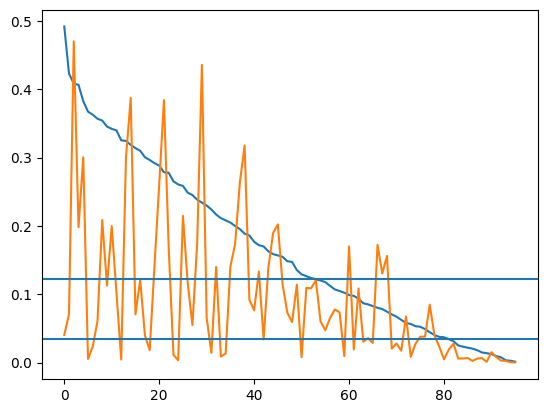

In [30]:
plt.plot(S.detach().cpu())
plt.plot(torch.abs(U.T @ center).detach().cpu())
plt.axhline(y=S[rank].detach().cpu())
plt.axhline(y=S[rank1].detach().cpu())

In [18]:
# tests for 3rd component

Vh.T.shape, signal.shape

(torch.Size([96, 96]), torch.Size([64, 96, 80, 80]))

In [17]:
shortened_dotp = torch.abs(U.T @ center)[:rank]

correlated   = torch.nonzero(shortened_dotp >= S[rank], as_tuple=True)[0]
uncorrelated = torch.nonzero(shortened_dotp <  S[rank], as_tuple=True)[0]
len(correlated), len(uncorrelated)

(59, 22)

In [18]:
U_r = U[:, :rank]
S_r = S[:rank]
Vh_r = Vh[:, :rank]

out_ch, in_ch, kH, kW = convolution.weight.shape

# аппроксимированные веса
# W_approx = (U_r @ torch.diag(S_r) @ Vh_r.T).view_as(W)

conv1 = nn.Conv2d(in_channels=in_ch,
                      out_channels=rank,
                      kernel_size=(kH, kW),
                      stride=convolution.stride,
                      padding=convolution.padding,
                      dilation=convolution.dilation,
                      groups=convolution.groups,
                      bias=False).cuda()
import torch.nn.functional as F

W1 = Vh_r.T.contiguous().view(rank, in_ch // convolution.groups, kH, kW)
# conv1 = F.conv2d(signal, W1,
#                       stride=convolution.stride,
#                       padding=convolution.padding,
#                       dilation=convolution.dilation,
#                       groups=convolution.groups
#                       )

conv2 = nn.Conv2d(in_channels=rank,
                    out_channels=out_ch,
                    kernel_size=1,
                    stride=1,
                    padding=0,
                    bias=True if convolution.bias is not None else False).cuda()

W2 = (U_r * S_r).contiguous().view(out_ch, rank, 1, 1)
# signal_after_conv_svd = F.conv2d(conv1, W2,
#                                  stride=1,
#                                  padding=0,
#                                  bias=convolution.bias
#                                  )

# Заполняем веса первой свёртки (Vh_r^T)
conv1.weight.data.copy_(W1)

# Заполняем веса второй свёртки (U_r * Σ_r)
conv2.weight.data.copy_(W2)

# Переносим bias, если был
if convolution.bias is not None:
    conv2.bias.data.copy_(convolution.bias.data)

# torch.norm(signal_after_conv_true - signal_after_conv_svd)

In [19]:
import torch.nn.functional as F

# signal_after_conv_svd = F.conv2d(
#     signal, W_approx, convolution.bias,
#     stride=convolution.stride,
#     padding=convolution.padding,
#     dilation=convolution.dilation,
#     groups=convolution.groups
# )

signal_after_conv_svd = conv2(conv1(signal))

torch.norm(signal_after_conv_true - signal_after_conv_svd) # 44.5 for 0.85 # 24 for 0.9 # 92.3 for 0.8
# for 3x3 0.85 - 70

tensor(44.4856, device='cuda:0', grad_fn=<CopyBackwards>)

In [20]:
signal_after_conv_svd.shape

torch.Size([64, 96, 80, 80])

In [21]:
# keep_indices = torch.tensor(keep_indices, device=W.device)
U_corr = U_r[:, correlated]
S_corr = S_r[correlated]
Vh_corr = Vh_r[:, correlated]

# 3. Сборка обратно
# W_correlated = (U_corr @ torch.diag(S_corr) @ Vh_corr.t()).view_as(W_approx)

conv1_corr = nn.Conv2d(in_channels=in_ch,
                      out_channels=len(correlated),
                      kernel_size=(kH, kW),
                      stride=convolution.stride,
                      padding=convolution.padding,
                      dilation=convolution.dilation,
                      groups=convolution.groups,
                      bias=False).cuda()
W1_corr = Vh_corr.T.contiguous().view(len(correlated), in_ch // convolution.groups, kH, kW)
conv1_corr.weight.data.copy_(W1_corr)

conv2_corr = nn.Conv2d(in_channels=len(correlated),
                    out_channels=out_ch,
                    kernel_size=1,
                    stride=1,
                    padding=0,
                    bias=True if convolution.bias is not None else False).cuda()
W2_corr = (U_corr * S_corr).contiguous().view(out_ch, len(correlated), 1, 1)
conv2_corr.weight.data.copy_(W2_corr)
if convolution.bias is not None:
    conv2_corr.bias.data.copy_(convolution.bias.data)

W_eff = W2_corr.view(W2_corr.size()[0], W2_corr.size()[1], -1).sum(dim=2)  # shape: [out_ch, in_ch]
W_pinv = torch.pinverse(W_eff)
center_before_conv_corr = W_pinv @ center

signal_corr_after_1_conv = conv1_corr(signal)
signal_corr_after_center = signal_corr_after_1_conv - center_before_conv_corr.view(1, -1, 1, 1)
signal_after_conv_correlated = conv2_corr(signal_corr_after_center)

# signal_after_conv_correlated = conv2_corr(conv1_corr(signal))

# signal_after_conv_correlated = F.conv2d(
#     signal, W_correlated, convolution.bias,
#     stride=convolution.stride,
#     padding=convolution.padding,
#     dilation=convolution.dilation,
#     groups=convolution.groups
# )

In [30]:
# keep_indices = torch.tensor(keep_indices, device=W.device)
U_uncorr = U_r[:, uncorrelated]
S_uncorr = S_r[uncorrelated]
Vh_uncorr = Vh_r[:, uncorrelated]

# 3. Сборка обратно
# W_uncorrelated = (U_uncorr @ torch.diag(S_uncorr) @ Vh_uncorr.t()).view_as(W_approx)

conv1_uncorr = nn.Conv2d(in_channels=in_ch,
                      out_channels=len(uncorrelated),
                      kernel_size=(kH, kW),
                      stride=convolution.stride,
                      padding=convolution.padding,
                      dilation=convolution.dilation,
                      groups=convolution.groups,
                      bias=False).cuda()
W1_uncorr = Vh_uncorr.T.contiguous().view(len(uncorrelated), in_ch // convolution.groups, kH, kW)
conv1_uncorr.weight.data.copy_(W1_uncorr)

conv2_uncorr = nn.Conv2d(in_channels=len(uncorrelated),
                    out_channels=out_ch,
                    kernel_size=1,
                    stride=1,
                    padding=0,
                    bias=True if convolution.bias is not None else False).cuda()
W2_uncorr = (U_uncorr * S_uncorr).contiguous().view(out_ch, len(uncorrelated), 1, 1)
conv2_uncorr.weight.data.copy_(W2_uncorr)
if convolution.bias is not None:
    conv2_uncorr.bias.data.copy_(convolution.bias.data)

W_eff = W2_uncorr.view(W2_uncorr.size()[0], W2_uncorr.size()[1], -1).sum(dim=2)  # shape: [out_ch, in_ch]
W_pinv = torch.pinverse(W_eff)
center_before_conv_uncorr = W_pinv @ center

signal_uncorr_after_1_conv = conv1_uncorr(signal)
signal_uncorr_after_center = signal_uncorr_after_1_conv #- center_before_conv_uncorr.view(1, -1, 1, 1)
signal_after_conv_uncorrelated = conv2_uncorr(signal_uncorr_after_center)

# signal_after_conv_uncorrelated = conv2_uncorr(conv1_uncorr(signal))


# signal_after_conv_uncorrelated = F.conv2d(
#     signal, W_uncorrelated, convolution.bias,
#     stride=convolution.stride,
#     padding=convolution.padding,
#     dilation=convolution.dilation,
#     groups=convolution.groups
# )

In [31]:
signal_after_bn_svd2matr = (signal_after_conv_correlated + signal_after_conv_uncorrelated) / torch.sqrt(bn.running_var.view(1, -1, 1, 1) + bn.eps) * bn.weight.view(1, -1, 1, 1) + bn.bias.view(1, -1, 1, 1)

In [32]:
torch.norm(signal_after_bn_true - signal_after_bn_svd2matr)

tensor(292.1036, device='cuda:0', grad_fn=<CopyBackwards>)

In [ ]:
# - bn.running_mean.view(1, -1, 1, 1)) / torch.sqrt(bn.running_var.view(1, -1, 1, 1) + bn.eps) * bn.weight.view(1, -1, 1, 1) + bn.bias.view(1, -1, 1, 1)

In [23]:
'''
for 1x1 0.85
(tensor(2.3052e-07, device='cuda:0'),
 tensor(2.0338, device='cuda:0'),
 tensor(2.0351, device='cuda:0'),
 tensor(7441.5879, device='cuda:0'))
'''

'''
for 3x3 0.85
(tensor(9.0303e-07, device='cuda:0'),
 tensor(2.9930, device='cuda:0'),
 tensor(3.0190, device='cuda:0'),
 tensor(3339.0386, device='cuda:0'))
'''

torch.norm(W_correlated + W_uncorrelated - W_approx), torch.norm(W_approx), torch.norm(W), torch.norm(signal)

(tensor(2.3052e-07, device='cuda:0'),
 tensor(2.0338, device='cuda:0'),
 tensor(2.0351, device='cuda:0'),
 tensor(7441.5879, device='cuda:0'))

In [47]:
'''
for 1x1 0.85
(tensor(44.4856, device='cuda:0', grad_fn=<CopyBackwards>),
 tensor(1602.6787, device='cuda:0', grad_fn=<CopyBackwards>))
 '''

'''
for 3x3 0.85
(tensor(70.6630, device='cuda:0', grad_fn=<CopyBackwards>),
 tensor(989.4926, device='cuda:0', grad_fn=<CopyBackwards>))
 '''
torch.norm(signal_after_conv_true - signal_after_conv_correlated - signal_after_conv_uncorrelated), torch.norm(signal_after_conv_true)

(tensor(44.4856, device='cuda:0', grad_fn=<CopyBackwards>),
 tensor(1602.6787, device='cuda:0', grad_fn=<CopyBackwards>))

In [25]:
signal_after_bn_svd = bn(signal_after_conv_svd)
signal_after_bn_correlated = bn(signal_after_conv_correlated)
signal_after_bn_uncorrelated = bn(signal_after_conv_uncorrelated)
# signal_after_bn_true or signal_after_bn_true_

def bn_selfmade(m, x, center : bool=True):
    c = m.running_mean.view(1, -1, 1, 1) if center else 0
    return (x - c) / torch.sqrt(m.running_var.view(1, -1, 1, 1) + m.eps) * m.weight.view(1, -1, 1, 1) + m.bias.view(1, -1, 1, 1)

signal_after_bn_svd_selfmade = bn_selfmade(bn, signal_after_conv_svd)

# torch.norm(signal_after_bn_svd_selfmade - signal_after_bn_svd)

forward hook used
forward hook used
forward hook used


In [23]:
aaa = (signal_after_conv_correlated + signal_after_conv_uncorrelated - bn.running_mean.view(1, -1, 1, 1))\
    / torch.sqrt(bn.running_var.view(1, -1, 1, 1) + bn.eps) * bn.weight.view(1, -1, 1, 1) + bn.bias.view(1, -1, 1, 1)

In [32]:
aboba = bn(signal_after_conv_correlated + signal_after_conv_uncorrelated)

torch.norm(aboba - signal_after_bn_true)

forward hook used


tensor(189.5049, device='cuda:0', grad_fn=<CopyBackwards>)